# cosmos_pose2vec — a word2vec-style learned pose encoder

Learns a spatial embedding of maze **poses** by training a word2vec-style network on rat
trajectories, then exports it as a new `ENCODER_TYPE = 'pose2vec'` lookup that the Decision
Transformer stack can consume.

The analogy is literal:

| word2vec | cosmos_pose2vec |
|---|---|
| word | pose — a grid position plus a heading, `(x, y, dir)` |
| vocabulary | the **196** poses occupiable in the fully-open maze |
| one-hot word vector | one-hot pose vector, length 196 |
| sentence | one yoked session's ordered pose sequence (PI+VC rats) |
| "predict the neighbouring word" | "predict the neighbouring position on the grid" |
| learned word embedding | learned pose embedding → **the encoder** |

If the idea works, individual hidden units should end up looking like place fields or
heading-tuned cells. The last section is the test of that claim.

Plan: `docs/cosmos_pose2vec_plan.md`. Brief: `docs/cosmos_pose2vec_kickoff.md`.

## 0. Colab bootstrap

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ryangrg/corner-maze-rl/blob/main/notebooks/cosmos_pose2vec.ipynb)

Same bootstrap as `10_vanilla_dt.ipynb` — clones the repo, installs the package, mounts Drive,
and starts a background sync of `data/runs/`. No-op locally. This notebook trains a small model
and runs fine on CPU; a GPU runtime is not required.

In [1]:
# ── Colab bootstrap (no-op locally; local-write + periodic Drive sync) ─
import sys
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    import os, subprocess, threading, atexit
    from pathlib import Path

    # ── Customise for your setup ──────────────────────────────────────
    REPO_URL          = 'https://github.com/ryangrg/corner-maze-rl.git'
    REPO_BRANCH       = 'main'
    REPO_DIR          = Path('/content/corner-maze-rl')
    USE_DRIVE         = True   # set False to skip Drive entirely
    DRIVE_ROOT        = Path('/content/drive/MyDrive/corner-maze-rl-colab')
    SYNC_INTERVAL_SEC = 120    # background rsync cadence
    # ──────────────────────────────────────────────────────────────────

    # 1. Clone repo (brings lookups + yoked dataset; both are committed)
    if not REPO_DIR.exists():
        subprocess.check_call(['git', 'clone', '--depth=1',
                               '-b', REPO_BRANCH, REPO_URL, str(REPO_DIR)])
    else:
        print(f'  repo already at {REPO_DIR}')

    # 2. Install package into the KERNEL's Python (sys.executable, not PATH pip —
    #    on Colab those can differ and PATH-pip installs are invisible to the kernel).
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(REPO_DIR)])

    # 3. Editable installs add a .pth entry, but the kernel's sys.path was built at
    #    startup and doesn't re-scan .pth files. Add the src dir manually so `import
    #    corner_maze_rl` works without a runtime restart.
    src_dir = str(REPO_DIR / 'src')
    if src_dir not in sys.path:
        sys.path.insert(0, src_dir)

    # 4. data/runs is ALWAYS a real local dir on the VM disk — never a symlink.
    #    This keeps writes resilient to mid-run Drive disconnects.
    local_runs = REPO_DIR / 'data' / 'runs'
    local_runs.mkdir(parents=True, exist_ok=True)

    # 5. Try Drive mount; failure just disables sync (training still works).
    drive_runs   = None
    drive_status = 'skipped (USE_DRIVE=False)'
    if USE_DRIVE:
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            if not DRIVE_ROOT.exists():
                drive_status = f'mounted, but {DRIVE_ROOT} missing — sync disabled'
            else:
                drive_runs = DRIVE_ROOT / 'runs'
                drive_runs.mkdir(exist_ok=True)
                drive_status = f'mounted at {DRIVE_ROOT}'
        except Exception as e:
            drive_status = f'mount failed ({type(e).__name__}) — sync disabled'

    # 6. Public sync helper — call from any cell with verbose=True for feedback.
    _sync_lock = threading.Lock()

    def sync_runs_to_drive(verbose: bool = False) -> tuple[bool, str]:
        """rsync local data/runs/ → Drive corner-maze-rl-colab/runs/.

        Returns (ok, message). Skips silently if Drive isn't reachable.
        Safe to call concurrently — uses a lock to prevent overlapping rsyncs.
        """
        if drive_runs is None:
            return (False, 'no drive target')
        if not _sync_lock.acquire(blocking=False):
            return (False, 'sync already in flight')
        try:
            result = subprocess.run(
                ['rsync', '-a', '--update',
                 str(local_runs) + '/', str(drive_runs) + '/'],
                capture_output=True, text=True, timeout=300,
            )
            ok  = (result.returncode == 0)
            msg = 'synced' if ok else f'rc={result.returncode}: {result.stderr.strip()[:200]}'
            if verbose:
                print(f'  [drive sync] {msg}')
            return (ok, msg)
        except Exception as e:
            if verbose:
                print(f'  [drive sync] {type(e).__name__}: {e}')
            return (False, f'{type(e).__name__}: {e}')
        finally:
            _sync_lock.release()

    # 7. Background sync — daemon thread, silent. Dies with the kernel.
    _sync_stop = threading.Event()
    def _sync_loop():
        while not _sync_stop.wait(SYNC_INTERVAL_SEC):
            sync_runs_to_drive(verbose=False)

    if drive_runs is not None:
        threading.Thread(target=_sync_loop, daemon=True).start()
        # Final sync on kernel exit so the last cycle's writes catch up.
        atexit.register(lambda: (_sync_stop.set(), sync_runs_to_drive(verbose=True)))
        sync_status = f'active (every {SYNC_INTERVAL_SEC}s + final on exit)'
    else:
        sync_status = 'inactive (runs are EPHEMERAL — download before disconnect)'

    # 8. cd into notebooks/ so REPO_ROOT = Path.cwd().parent resolves
    os.chdir(REPO_DIR / 'notebooks')

    print(f'\n✓ Colab bootstrap complete')
    print(f'  repo:    {REPO_DIR}  (branch={REPO_BRANCH})')
    print(f'  cwd:     {Path.cwd()}')
    print(f'  python:  {sys.executable}')
    print(f'  drive:   {drive_status}')
    print(f'  runs:    {local_runs}  (always local; never a symlink)')
    print(f'  sync:    {sync_status}')
    print(f'\n  manual sync any time: sync_runs_to_drive(verbose=True)')
else:
    print('✓ local environment — bootstrap skipped')

✓ local environment — bootstrap skipped


## 1. Configuration

The knobs the design calls for are `HIDDEN_UNITS` (the single hidden layer's width),
`WINDOW_RADIUS` (how far along the trajectory counts as "adjacent"), and `CAUSAL`.

The model is classic skip-gram: `one-hot(196) → hidden(HIDDEN_UNITS) → softmax(196)`. The one
hidden layer *is* the embedding, so `HIDDEN_UNITS` is the hidden width, the embedding dimension,
and the export width all at once — `(196, HIDDEN_UNITS)`, one row per pose. Keep it **below
196**: fewer dimensions than poses is the bottleneck that forces spatial structure.

**`CAUSAL` semantics**: `True` predicts only the poses that come *after* the centre pose — the
"predict the next position" framing, which respects the arrow of time. `False` uses a symmetric
window, `WINDOW_RADIUS` steps before *and* after, which is standard skip-gram and treats
adjacency as direction-agnostic.

In [2]:
from __future__ import annotations
from pathlib import Path
import torch

# ── Experiment identity ───────────────────────────────────────────────
RUN_NAME = 'pose2vec-pi_vc-pooled'

# ── Model / trainer hyperparameters ───────────────────────────────────
# Classic skip-gram, one hidden layer, no non-linearity:
#     one-hot(196) -> hidden(HIDDEN_UNITS) -> softmax(196)
# The hidden layer IS the embedding, so this one number is the hidden width, the embedding
# dimension, and the exported encoder width all at once.
HIDDEN_UNITS = 60   # KEEP BELOW 196. Fewer dimensions than the 196 poses is the bottleneck
                    # that forces poses to share dimensions — which is what turns into
                    # overlapping, place-field-like tuning. Try 16 for a tight bottleneck,
                    # 120 for a loose one. At >= 196 there is no bottleneck and the model can
                    # memorise transitions without learning anything spatial.

WINDOW_RADIUS = 2       # adjacency along the trajectory the model should learn
CAUSAL        = True    # True  = context is the poses AFTER the centre (predict-next)
                        # False = symmetric window, WINDOW_RADIUS before AND after
ARCHITECTURE  = 'skipgram'   # v1 implements skip-gram only ('cbow' would need a pad token)

# ── Subjects ──────────────────────────────────────────────────────────
TRAINING_GROUP = 'pi_vc'                # 'pi' | 'pi_vc' | 'vc' | 'pi_vc_f1'

# ── Usable PI+VC subjects — all 17 are in the manuscript roster ────────
# Acquisition sessions / steps available in actions_real_pretrial:
#   CM000   7 / 12,786      CM007   9 / 11,624      CM014  10 / 18,890
#   CM001   6 / 11,462      CM008   3 /  6,827      CM015  11 / 21,253
#   CM002   7 / 12,355      CM009   7 / 16,065      CM016   5 / 11,005
#   CM003   8 / 14,069      CM010   5 / 10,951      CM017   9 / 12,346
#   CM004   8 / 20,048      CM011   5 / 10,016      CM018   9 / 13,449
#   CM005   6 / 11,801
#   CM006   3 /  7,117             all 17 pooled = 118 sessions / 222,064 steps
# Smallest: CM006 / CM008 (3 sessions).  Largest: CM015 (11 sessions), CM004 (20k steps).
SUBJECTS      = 'all'   # 'all' → every subject listed above,
                        # or an explicit list, e.g. ['CM004', 'CM015']
POOL_SUBJECTS = True    # True  = ONE embedding trained on all SUBJECTS pooled (recommended:
                        #         the embedding describes the MAZE, not an animal)
                        # False = one independent embedding per subject

# ── Corpus ────────────────────────────────────────────────────────────
CORPUS_SOURCE       = 'real_pretrial'   # 'real_pretrial' | 'synthetic_pretrial' | 'both'
USE_CANONICAL_FRAME = True              # rotate PI/PI+VC so the cue sits at North

# ── Optimisation ──────────────────────────────────────────────────────
EPOCHS        = 20
BATCH_SIZE    = 4096
LEARNING_RATE = 5e-3
SEED          = 0

# ── Derived / fixed ───────────────────────────────────────────────────
ENCODER_TYPE = 'pose2vec'
assert isinstance(HIDDEN_UNITS, int) and HIDDEN_UNITS >= 1, 'HIDDEN_UNITS must be an int >= 1'

# The hidden layer is the representation, so its width is the exported width.
EXPORT_DIM = HIDDEN_UNITS

GROUP_ALIASES = {'pi': 'PI', 'pi_vc': 'PI+VC', 'vc': 'VC', 'pi_vc_f1': 'PI+VC_f1'}
assert TRAINING_GROUP in GROUP_ALIASES, f'unknown TRAINING_GROUP={TRAINING_GROUP!r}'

# ── Manuscript scope ──────────────────────────────────────────────────
# 8 of the 56 yoked subjects sit outside manuscript scope and must not be used for
# new training runs or published comparisons (README.md, "Manuscript subject roster").
# None of them are PI+VC, so the default group is unaffected — but SUBJECTS='all'
# must still exclude them for the other groups.
OUT_OF_MANUSCRIPT_SCOPE = {
    'CM030', 'CM032', 'CM033',            # PI
    'CM059',                              # PI+VC_f1
    'CM028', 'CM034', 'CM039', 'CM048',   # VC
}
RESTRICT_TO_MANUSCRIPT = True   # applies to SUBJECTS='all'; an explicit list only warns
assert ARCHITECTURE == 'skipgram', 'v1 implements skip-gram only'
assert WINDOW_RADIUS >= 1, 'WINDOW_RADIUS must be >= 1'

FORCE_CPU = False
if FORCE_CPU:
    DEVICE = 'cpu'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

REPO_ROOT   = Path.cwd().parent
DATASET_DIR = REPO_ROOT / 'data' / 'yoked' / 'dataset'
LOOKUPS_DIR = REPO_ROOT / 'data' / 'lookups'

torch.manual_seed(SEED)

print(f'RUN_NAME      = {RUN_NAME}')
print(f'architecture  = one-hot(196) -> hidden({HIDDEN_UNITS}) -> softmax(196)')
print(f'window        = radius {WINDOW_RADIUS}, {"causal" if CAUSAL else "acausal"}')
print(f'subjects      = {SUBJECTS}  (pooled={POOL_SUBJECTS})')
print(f'DEVICE        = {DEVICE}')
# Print only the folder name — this notebook is committed to a public, student-facing
# repo, and an absolute home path in a stored output would leak into it.
print(f'REPO_ROOT     = {REPO_ROOT.name}/')

RUN_NAME      = pose2vec-pi_vc-pooled
architecture  = one-hot(196) -> hidden(60) -> softmax(196)
window        = radius 2, causal
subjects      = all  (pooled=True)
DEVICE        = mps
REPO_ROOT     = corner-maze-rl/


## 2. Pose vocabulary — the 196 "words"

The maze is a 13×13 MiniGrid, but only **49 cells** are ever occupiable: a 3×3 lattice of
corridors (45 cells) plus the 4 corner wells. With 4 headings that gives a vocabulary of
**196 poses**.

The vocabulary is derived from the environment rather than hardcoded — the env grid is this
repo's ground truth. `session_type='exposure'` is the Exposure A layout, i.e. the maze with no
barriers up, which is a strict superset of every barrier configuration used in acquisition.

**No sentinel tokens.** There is no `<START>`, `<END>`, `<PAD>`, or `<UNK>`. Skip-gram predicts
context *from* a centre, so unlike an autoregressive model it has nothing to bootstrap — the
window simply clips at the sentence edge. Emitting individual `(centre, context)` pairs means
every example is complete, so no padding is needed. And every exported row must correspond to a
real `(x, y, dir)` for the DT to index it, so sentinel rows would be junk.

In [3]:
import warnings
import numpy as np

# pygame (pulled in by the env) emits a pkg_resources deprecation warning on import. Silence
# it so stored outputs stay clean: the stderr trace embeds a local virtualenv path, and this
# notebook is committed to a public, student-facing repo.
warnings.filterwarnings('ignore', message='pkg_resources is deprecated')

from corner_maze_rl.env.corner_maze_env import CornerMazeEnv

N_DIR     = 4
DIR_NAMES = {0: 'East', 1: 'South', 2: 'West', 3: 'North'}   # MiniGrid convention

_env = CornerMazeEnv(session_type='exposure', render_mode=None)
_env.reset(seed=0)
GRID_W, GRID_H = _env.width, _env.height


def _is_occupiable(env, x: int, y: int) -> bool:
    """A cell the agent can stand on: empty, or an object that permits overlap."""
    cell = env.grid.get(x, y)
    return cell is None or (hasattr(cell, 'can_overlap') and cell.can_overlap())


OCCUPIABLE_CELLS = sorted((x, y) for x in range(GRID_W) for y in range(GRID_H)
                          if _is_occupiable(_env, x, y))
_env.close()

# Canonical ordering: x-major, then y, then heading.
POSE_VOCAB  = [(x, y, d) for (x, y) in OCCUPIABLE_CELLS for d in range(N_DIR)]
POSE_TO_IDX = {p: i for i, p in enumerate(POSE_VOCAB)}
VOCAB_SIZE  = len(POSE_VOCAB)

assert len(OCCUPIABLE_CELLS) == 49, f'expected 49 occupiable cells, got {len(OCCUPIABLE_CELLS)}'
assert VOCAB_SIZE == 196, f'expected 196 poses, got {VOCAB_SIZE}'
assert VOCAB_SIZE == len(OCCUPIABLE_CELLS) * N_DIR

# Dense (x, y, d) -> row lookup; -1 marks "not in vocabulary" so escapes are detectable.
POSE_INDEX_GRID = np.full((GRID_W, GRID_H, N_DIR), -1, dtype=np.int32)
for _pose, _i in POSE_TO_IDX.items():
    POSE_INDEX_GRID[_pose] = _i


def rotate_pos(x, y, n):
    """n CCW rotations in screen coords (y-down): (x, y) -> (y, (W-1) - x)."""
    for _ in range(n % 4):
        x, y = y, (GRID_W - 1) - x
    return x, y


# The canonical frame rotates PI/PI+VC sessions. If the occupiable set were not closed under
# that rotation, canonicalisation could produce an out-of-vocabulary pose.
_cellset = set(OCCUPIABLE_CELLS)
for _n in (1, 2, 3):
    _img = {rotate_pos(x, y, _n) for (x, y) in OCCUPIABLE_CELLS}
    assert _img == _cellset, f'occupiable set not closed under {_n} rotation(s)'

print(f'grid            = {GRID_W} x {GRID_H}')
print(f'occupiable cells= {len(OCCUPIABLE_CELLS)}')
print(f'VOCAB_SIZE      = {VOCAB_SIZE}  ({len(OCCUPIABLE_CELLS)} cells x {N_DIR} headings)')
print(f'rotation closure= ok (1, 2, 3 CCW)')
print()
print('occupancy map  (row = y, col = x, "#" = occupiable):')
for _y in range(GRID_H):
    print('   ', ''.join('#' if (x, _y) in _cellset else '.' for x in range(GRID_W)))

grid            = 13 x 13
occupiable cells= 49
VOCAB_SIZE      = 196  (49 cells x 4 headings)
rotation closure= ok (1, 2, 3 CCW)

occupancy map  (row = y, col = x, "#" = occupiable):
    .............
    .#.........#.
    ..#########..
    ..#...#...#..
    ..#...#...#..
    ..#...#...#..
    ..#########..
    ..#...#...#..
    ..#...#...#..
    ..#...#...#..
    ..#########..
    .#.........#.
    .............


## 3. Build the pose corpus — the "sentences"

One sentence per session: the rat's poses in step order. A context window must never span two
sessions, so sentences stay as a *list* of sequences and are never concatenated.

Poses come straight out of the parquet (`grid_x`, `grid_y`, `direction`) — no environment
replay is needed.

**Canonical frame.** PI and PI+VC sessions are rotated so the cue always sits at North, matching
the rat's path-integration frame. The rotation count is the cue index of the first trial. Note
the direction formula is `(d - n) % 4` — the legacy `(d + n) % 4` is wrong for odd `n` and only
accidentally right at `n = 2`.

In [4]:
import json
import pandas as pd

_ACTION_TABLES = {
    'real_pretrial':      ['actions_real_pretrial.parquet'],
    'synthetic_pretrial': ['actions_synthetic_pretrial.parquet'],
    'both':               ['actions_real_pretrial.parquet', 'actions_synthetic_pretrial.parquet'],
}
assert CORPUS_SOURCE in _ACTION_TABLES, f'unknown CORPUS_SOURCE={CORPUS_SOURCE!r}'

subjects_df = pd.read_parquet(DATASET_DIR / 'subjects.parquet')
sessions_df = pd.read_parquet(DATASET_DIR / 'sessions.parquet')

GROUP_LABEL    = GROUP_ALIASES[TRAINING_GROUP]
_group_rows    = subjects_df[subjects_df['training_group'] == GROUP_LABEL]
_group_names   = sorted(_group_rows['subject_name'].tolist())
NAME_TO_SID    = dict(zip(_group_rows['subject_name'], _group_rows['subject_id']))

if isinstance(SUBJECTS, str) and SUBJECTS == 'all':
    SELECTED_SUBJECTS = [s for s in _group_names
                         if not (RESTRICT_TO_MANUSCRIPT and s in OUT_OF_MANUSCRIPT_SCOPE)]
    _excluded = sorted(set(_group_names) - set(SELECTED_SUBJECTS))
    if _excluded:
        print(f'  excluded {len(_excluded)} out-of-manuscript-scope subject(s): {_excluded}')
else:
    SELECTED_SUBJECTS = list(SUBJECTS)
    _unknown = set(SELECTED_SUBJECTS) - set(_group_names)
    assert not _unknown, f'not {GROUP_LABEL} subjects: {sorted(_unknown)}'
    _oos = sorted(set(SELECTED_SUBJECTS) & OUT_OF_MANUSCRIPT_SCOPE)
    if _oos:
        print(f'  [warn] explicitly selected OUT-OF-MANUSCRIPT-SCOPE subject(s): {_oos} — '
              f'not valid for published comparisons')
assert SELECTED_SUBJECTS, 'no subjects selected'

ROTATE_TO_CANONICAL = USE_CANONICAL_FRAME and GROUP_LABEL in ('PI', 'PI+VC', 'PI+VC_f1')
print(f'group={GROUP_LABEL}  subjects={len(SELECTED_SUBJECTS)}  rotate={ROTATE_TO_CANONICAL}')

# Load the action table(s) once; tag rows by source so 'both' keeps the two variants of a
# session as separate sentences instead of silently interleaving them.
_frames = []
for _fname in _ACTION_TABLES[CORPUS_SOURCE]:
    _f = pd.read_parquet(DATASET_DIR / _fname)
    _f['_src'] = _fname
    _frames.append(_f)
ACTIONS_ALL = pd.concat(_frames, ignore_index=True) if len(_frames) > 1 else _frames[0]

_required = {'session_id', 'step', 'grid_x', 'grid_y', 'direction'}
assert _required <= set(ACTIONS_ALL.columns), f'missing columns: {_required - set(ACTIONS_ALL.columns)}'


def _n_rotations_for(row) -> int | None:
    """Rotations to canonicalise a session. None => drop (cue varies within session)."""
    if not ROTATE_TO_CANONICAL:
        return 0
    tc = row.get('trial_configs')
    if tc is None or (isinstance(tc, float) and np.isnan(tc)):
        return 0
    try:
        tc = json.loads(tc) if isinstance(tc, str) else list(tc)
    except Exception:
        return 0
    if len(tc) == 0:
        return 0
    cues = {int(t[1]) for t in tc}
    if len(cues) > 1:
        return None
    return int(next(iter(cues)))


def build_sentences(subject_names) -> tuple[list[np.ndarray], pd.DataFrame]:
    """One int32 pose-index sequence per session, for the named subjects."""
    sids = {NAME_TO_SID[n] for n in subject_names}
    sess = sessions_df[sessions_df['subject_id'].isin(sids)]

    sid_to_nrot, dropped = {}, []
    for _, row in sess.iterrows():
        n = _n_rotations_for(row)
        if n is None:
            dropped.append(int(row['session_id']))
        else:
            sid_to_nrot[int(row['session_id'])] = n
    if dropped:
        print(f'  [warn] dropping {len(dropped)} multi-cue session(s): {dropped}')

    df = ACTIONS_ALL[ACTIONS_ALL['session_id'].isin(sid_to_nrot)].copy()
    if df.empty:
        return [], df

    n_rot = df['session_id'].map(sid_to_nrot).to_numpy(np.int32)
    x = df['grid_x'].to_numpy(np.int32)
    y = df['grid_y'].to_numpy(np.int32)
    d = df['direction'].to_numpy(np.int32)

    rx, ry = x.copy(), y.copy()
    for n_val in sorted(set(sid_to_nrot.values())):
        if n_val == 0:
            continue
        m = n_rot == n_val
        cx, cy = x[m], y[m]
        for _ in range(n_val % 4):
            cx, cy = cy, (GRID_W - 1) - cx
        rx[m], ry[m] = cx, cy
    rd = (d - n_rot) % 4                      # corrected formula; legacy (d + n) is wrong

    idx = POSE_INDEX_GRID[rx, ry, rd]
    n_escape = int((idx < 0).sum())
    assert n_escape == 0, (
        f'{n_escape} pose(s) outside the vocabulary — the corpus must be a subset of the '
        f'fully-open maze'
    )

    df['pose_idx'] = idx
    df = df.sort_values(['_src', 'session_id', 'step'], kind='stable')
    sentences = [g['pose_idx'].to_numpy(np.int32)
                 for _, g in df.groupby(['_src', 'session_id'], sort=False)]
    return sentences, df


CORPUS = {}
if POOL_SUBJECTS:
    CORPUS['pooled_' + TRAINING_GROUP] = SELECTED_SUBJECTS
else:
    for _s in SELECTED_SUBJECTS:
        CORPUS['subject_' + _s] = [_s]

SENTENCES = {}
for _label, _subs in CORPUS.items():
    _sents, _df = build_sentences(_subs)
    SENTENCES[_label] = _sents
    _flat  = np.concatenate(_sents) if _sents else np.empty(0, np.int32)
    _cov   = len(np.unique(_flat))
    _counts = np.bincount(_flat, minlength=VOCAB_SIZE)
    print(f'  {_label:22s} sessions={len(_sents):4d}  steps={len(_flat):7,d}  '
          f'poses covered={_cov}/{VOCAB_SIZE}')
    # Pose frequency is heavily skewed — rats dwell in some poses far more than others.
    # The rarest rows are trained on very few examples; their embeddings are the least
    # trustworthy, which matters when reading the spatial maps in the last section.
    print(f'    {"":20s} frequency  min={_counts.min():,}  p50={int(np.percentile(_counts, 50)):,}  '
          f'max={_counts.max():,}  (skew {_counts.max() / max(_counts.min(), 1):.0f}:1)')

group=PI+VC  subjects=17  rotate=True
  pooled_pi_vc           sessions= 118  steps=222,064  poses covered=196/196
                         frequency  min=9  p50=870  max=5,942  (skew 660:1)


## 4. Training pairs

Skip-gram: each centre pose is paired with each pose in its context window. Built with numpy
slicing per sentence — a Python double loop over ~222k steps would be needlessly slow.

**Session edges.** A window must never span two sessions, which is why the corpus stays a
*list* of per-session arrays and is only ever concatenated *after* pairs are formed. A pose near
the end of a session simply produces fewer pairs; nothing wraps around or bleeds into the next
session.

Clipping costs `R(R+1)/2` pairs per session when causal and `R(R+1)` when acausal, for
`R = WINDOW_RADIUS` — 3 and 6 respectively at the default `R=2`. Across 118 sessions that is
~354 of ~444,000 pairs, under 0.1%. It is a boundary effect, not a bias worth correcting.

In [5]:
def make_pairs(sentences, radius: int, causal: bool):
    """(centre, context) index arrays. causal => context is strictly ahead of the centre."""
    offsets = list(range(1, radius + 1)) if causal else \
              [o for o in range(-radius, radius + 1) if o != 0]
    centres, contexts = [], []
    for s in sentences:
        for off in offsets:
            k = abs(off)
            if len(s) <= k:
                continue
            if off > 0:
                centres.append(s[:-k]);  contexts.append(s[k:])
            else:
                centres.append(s[k:]);   contexts.append(s[:-k])
    if not centres:
        return np.empty(0, np.int64), np.empty(0, np.int64)
    return (np.concatenate(centres).astype(np.int64),
            np.concatenate(contexts).astype(np.int64))


PAIRS, CENTRE_COVERAGE = {}, {}
for _label, _sents in SENTENCES.items():
    c, ctx = make_pairs(_sents, WINDOW_RADIUS, CAUSAL)
    PAIRS[_label] = (c, ctx)
    # Only poses that appear as a CENTRE receive gradient into the hidden/embedding matrix —
    # i.e. into the exported encoder. Anything else stays at initialisation (see Section 7).
    CENTRE_COVERAGE[_label] = set(np.unique(c).tolist())
    _untrained = VOCAB_SIZE - len(CENTRE_COVERAGE[_label])
    print(f'  {_label:22s} pairs={len(c):9,d}  '
          f'({"causal" if CAUSAL else "acausal"}, radius {WINDOW_RADIUS})  '
          f'centres={len(CENTRE_COVERAGE[_label])}/{VOCAB_SIZE}'
          + (f'  [{_untrained} rows will be UNTRAINED]' if _untrained else ''))

  pooled_pi_vc           pairs=  443,774  (causal, radius 2)  centres=196/196


## 5. Model

Classic skip-gram — one matrix in, one matrix out:

```
one-hot(196) → hidden(HIDDEN_UNITS) → softmax(196)
```

There is **no non-linearity** in the hidden layer, so multiplying the one-hot by the input
matrix simply *selects a row* — the hidden layer *is* the embedding. `nn.Embedding` computes
that row lookup directly, without ever materialising the length-196 one-hot vector. Those rows
are the pose representations: what the last section plots, and what gets exported.

**`HIDDEN_UNITS` is the only width** — the number of hidden units, the embedding dimension, and
the export width, one number. Keep it well below 196. With fewer dimensions than poses, the
poses are *forced* to share, and that sharing is what becomes overlapping, place-field-like
structure in the heatmaps. At 196 or above there is no bottleneck: every pose can claim a
private dimension and the model memorises the transition table without discovering anything
spatial.

**Which matrix is the encoder.** `hidden.weight` (196 × HIDDEN_UNITS) is the embedding and is
what gets exported; the output matrix is discarded after training. Conflating the two is the
classic word2vec implementation error.

**Initialisation** is the word2vec convention: small uniform on the embedding, zeros on the
output. (No orthogonal init — that is the repo's rule for ReLU policy/value nets; orthogonal
rows here would impose structure between poses, the very thing we are trying to measure.)

A full softmax over 196 classes is cheap, so there is no negative sampling and no hierarchical
softmax — those exist for vocabularies in the 10⁵–10⁶ range and would buy nothing here.

In [6]:
import torch.nn as nn


class Pose2Vec(nn.Module):
    """Classic skip-gram over maze poses:  one-hot(V) -> hidden(D) -> softmax(V).

    The hidden layer has no non-linearity, so a one-hot input selects a row of the input
    matrix — the hidden layer IS the embedding. Its rows are the pose representations: what
    the last section plots and what gets exported.
    """

    def __init__(self, vocab_size: int, hidden_units: int):
        super().__init__()
        assert hidden_units >= 1, 'HIDDEN_UNITS must be >= 1'
        self.vocab_size   = vocab_size
        self.hidden_units = hidden_units

        # one-hot(V) -> hidden(D), as a row lookup. THE encoder.
        self.hidden = nn.Embedding(vocab_size, hidden_units)
        bound = 0.5 / hidden_units
        nn.init.uniform_(self.hidden.weight, -bound, bound)          # word2vec convention

        # hidden(D) -> softmax(V). Discarded after training.
        self.output = nn.Linear(hidden_units, vocab_size, bias=False)
        nn.init.zeros_(self.output.weight)

    def forward(self, centre_idx: torch.Tensor) -> torch.Tensor:
        return self.output(self.hidden(centre_idx))      # (B,) -> (B, V)

    def pose_representations(self) -> np.ndarray:
        """(VOCAB_SIZE, HIDDEN_UNITS) — the hidden layer = the embedding = the encoder."""
        return self.hidden.weight.detach().cpu().numpy()


if HIDDEN_UNITS >= VOCAB_SIZE:
    print(f'[note] HIDDEN_UNITS={HIDDEN_UNITS} >= vocab {VOCAB_SIZE}: no bottleneck, so the '
          f'embedding can memorise transitions without learning shared spatial structure.')

_probe = Pose2Vec(VOCAB_SIZE, HIDDEN_UNITS)
print(_probe)
print(f'parameters = {sum(p.numel() for p in _probe.parameters()):,}')
print(f'encoder    = hidden.weight {tuple(_probe.hidden.weight.shape)}  (embedding, exported)')
del _probe

Pose2Vec(
  (hidden): Embedding(196, 60)
  (output): Linear(in_features=60, out_features=196, bias=False)
)
parameters = 23,520
encoder    = hidden.weight (196, 60)  (embedding, exported)


## 6. Train

training pooled_pi_vc  (443,774 pairs)


    epoch   0/20  loss=2.8653


    epoch   2/20  loss=1.3333


    epoch   4/20  loss=1.3197


    epoch   6/20  loss=1.3173


...

    epoch  12/20  loss=1.3148


    epoch  14/20  loss=1.3147


    epoch  16/20  loss=1.3140


    epoch  18/20  loss=1.3142


    epoch  19/20  loss=1.3140
  pooled_pi_vc: final loss=1.3140  (28.6s)


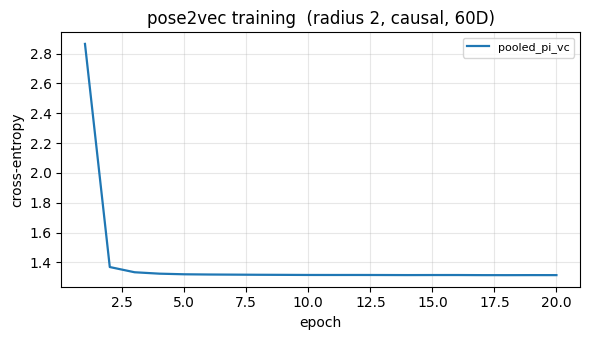

uniform-guess loss   = 5.2781
marginal-guess loss  = 4.7941


In [7]:
import time
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


def train_one(centres, contexts, label: str, seed: int = SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = Pose2Vec(VOCAB_SIZE, HIDDEN_UNITS).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    lossf = nn.CrossEntropyLoss()

    ds = TensorDataset(torch.from_numpy(centres), torch.from_numpy(contexts))
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

    history, t0 = [], time.time()
    for epoch in range(EPOCHS):
        model.train()
        total, n = 0.0, 0
        for cb, xb in dl:
            cb, xb = cb.to(DEVICE), xb.to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(cb), xb)
            loss.backward()
            opt.step()
            total += loss.item() * len(cb)
            n     += len(cb)
        history.append(total / max(n, 1))
        if epoch % max(EPOCHS // 10, 1) == 0 or epoch == EPOCHS - 1:
            print(f'    epoch {epoch:3d}/{EPOCHS}  loss={history[-1]:.4f}')
    print(f'  {label}: final loss={history[-1]:.4f}  ({time.time() - t0:.1f}s)')
    return model, history


MODELS, HISTORIES = {}, {}
for _label, (_c, _ctx) in PAIRS.items():
    print(f'training {_label}  ({len(_c):,} pairs)')
    MODELS[_label], HISTORIES[_label] = train_one(_c, _ctx, _label)

fig, ax = plt.subplots(figsize=(6, 3.5))
for _label, _h in HISTORIES.items():
    ax.plot(range(1, len(_h) + 1), _h, label=_label, lw=1.6)
ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy')
ax.set_title(f'pose2vec training  (radius {WINDOW_RADIUS}, '
             f'{"causal" if CAUSAL else "acausal"}, {HIDDEN_UNITS}D)')
ax.grid(alpha=0.3)
if len(HISTORIES) <= 6:
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# A useful reference point: predicting the marginal pose distribution.
_all_ctx = np.concatenate([c for _, c in PAIRS.values()])
_p = np.bincount(_all_ctx, minlength=VOCAB_SIZE) / len(_all_ctx)
print(f'uniform-guess loss   = {np.log(VOCAB_SIZE):.4f}')
print(f'marginal-guess loss  = {-(_p[_p > 0] * np.log(_p[_p > 0])).sum():.4f}')

## 7. Export as an encoder

Written in the same shape as `data/lookups/grid_cells_60d.npz` — a `keys` array giving the
`(x, y, dir)` triple for each row, and a `vectors` array of embeddings — but sized to the
196-pose vocabulary.

Row order is a **contract**: if `vectors[i]` does not correspond to `keys[i]`, the Decision
Transformer will silently train on scrambled states. Hence the consistency assertion against
`POSE_TO_IDX` and the reload round-trip.

Two extra arrays go into the npz beyond `keys`/`vectors`:

- **`trained_mask`** — `True` where the pose actually appeared as a centre and so received
  gradient into the encoder. Pooled runs cover all 196, but a single small subject may not
  (CM006 covers 167), and an uncovered row is exported *still at initialisation*. A consumer
  must check this rather than assume every row is meaningful.
- **`config`** — the run configuration as JSON. `WINDOW_RADIUS`, `CAUSAL`, `CORPUS_SOURCE` and
  `USE_CANONICAL_FRAME` all change what the vectors mean, and the array shapes alone cannot
  tell you which produced them.

The coordinate frame additionally gets its own filename suffix (`_raw` when *not*
canonicalised), because an unrotated lookup indexed with rotated `(x, y, d)` would silently
train on wrong states — and unlike a shape mismatch, no downstream assertion could catch it.

Note that `pose2vec` cannot reuse the `grid_cell` arithmetic index
(`((x-1)*11 + (y-1))*4 + d`) — that assumes the dense 484-pose space. A consumer must build a
`(x, y, d) -> row` dictionary from `keys`, the way `pose_visual` builds `label_to_row`. See
`docs/cosmos_pose2vec_plan.md` §2 for the exact notebook-10 touch-points.

In [8]:
LOOKUPS_DIR.mkdir(parents=True, exist_ok=True)

RUN_CONFIG = {
    'encoder_type':   ENCODER_TYPE,
    'hidden_units':   HIDDEN_UNITS,
    'window_radius':  WINDOW_RADIUS,
    'causal':         bool(CAUSAL),
    'architecture':   ARCHITECTURE,
    'training_group': GROUP_LABEL,
    'subjects':       list(SELECTED_SUBJECTS),
    'pooled':         bool(POOL_SUBJECTS),
    'corpus_source':  CORPUS_SOURCE,
    'canonical_frame': bool(ROTATE_TO_CANONICAL),
    'epochs':         EPOCHS,
    'seed':           SEED,
    'vocab_size':     VOCAB_SIZE,
}


def export_encoder(model: Pose2Vec, label: str, covered: set[int]) -> Path:
    keys = np.array(POSE_VOCAB, dtype=np.int32)
    # The hidden layer is the representation (= the embedding), so it is what ships.
    vectors = model.pose_representations().astype(np.float32)

    # ── Contract assertions ───────────────────────────────────────────
    assert keys.shape == (VOCAB_SIZE, 3), f'keys shape {keys.shape}'
    assert vectors.shape == (VOCAB_SIZE, EXPORT_DIM), f'vectors shape {vectors.shape}'
    assert np.isfinite(vectors).all(), 'non-finite values in the embedding'
    # Cross-check the two structures against each other (not a tautology): every key must
    # resolve, through POSE_TO_IDX, back to the row it sits in.
    assert all(POSE_TO_IDX[(int(x), int(y), int(d))] == i
               for i, (x, y, d) in enumerate(keys)), 'keys disagree with POSE_TO_IDX'

    # ── Untrained rows ────────────────────────────────────────────────
    trained_mask = np.zeros(VOCAB_SIZE, dtype=bool)
    if covered:
        trained_mask[sorted(covered)] = True
    n_untrained = int((~trained_mask).sum())
    if n_untrained:
        print(f'  [warn] {label}: {n_untrained}/{VOCAB_SIZE} rows never appeared as a centre '
              f'pose, so their embedding never received gradient. Check `trained_mask` '
              f'before relying on those rows.')

    # ── Filename encodes the frame, which changes what the vectors MEAN ──
    # Everything else that alters the vectors is recorded in `config`; the coordinate frame
    # gets its own suffix because an unrotated lookup indexed with rotated (x,y,d) would
    # silently train on wrong states and no assertion downstream could catch it.
    frame  = '' if ROTATE_TO_CANONICAL else '_raw'
    suffix = '' if label.startswith('pooled_') else f'_{label.replace("subject_", "")}'
    out    = LOOKUPS_DIR / f'pose2vec_{EXPORT_DIM}d{frame}{suffix}.npz'

    np.savez_compressed(out, keys=keys, vectors=vectors, trained_mask=trained_mask,
                        config=np.array(json.dumps(RUN_CONFIG)))

    # ── Round-trip ────────────────────────────────────────────────────
    z = np.load(out, allow_pickle=False)
    assert np.array_equal(z['keys'], keys), 'keys changed on reload'
    assert np.allclose(z['vectors'], vectors), 'vectors changed on reload'
    assert np.array_equal(z['trained_mask'], trained_mask), 'mask changed on reload'
    return out


for _label, _model in MODELS.items():
    _p = export_encoder(_model, _label, CENTRE_COVERAGE[_label])
    _z = np.load(_p)
    print(f'  wrote {_p.relative_to(REPO_ROOT)}  keys={_z["keys"].shape}  '
          f'vectors={_z["vectors"].shape}  trained={int(_z["trained_mask"].sum())}/{VOCAB_SIZE}')
print()
print(f'config stored in each npz: {json.dumps(RUN_CONFIG)[:160]}...')

  wrote data/lookups/pose2vec_60d.npz  keys=(196, 3)  vectors=(196, 60)  trained=196/196

config stored in each npz: {"encoder_type": "pose2vec", "hidden_units": 60, "window_radius": 2, "causal": true, "architecture": "skipgram", "training_group": "PI+VC", "subjects": ["CM000"...


## 8. Spatial tuning of hidden units

The payoff. For a chosen hidden unit, its weight across all 196 poses is plotted as four
heatmaps — one per heading — so any spatial or directional tuning is visible.

Non-occupiable cells are `NaN` and render as background, so the corridor lattice is plainly
visible. That catches a *gross* indexing error — if the maze shape does not appear at all, the
pose→row mapping is broken.

It is not sufficient on its own, though: the 49-cell lattice is symmetric under transpose and
under 90° rotation, so a transposed or rotated plot would still look like a maze. The x/y tick
labels and the filled **N** cue marker are what actually pin the orientation down. Check those,
not just the shape.

The colour scale is shared and symmetric across the four panels so they are comparable, and
`ylim` is inverted because this repo uses y-down screen coordinates.

Read the maps with the frequency skew from Section 3 in mind — the rarest poses are trained on
far fewer examples, so their cells are the least trustworthy.

model=pooled_pi_vc   units=60
most strongly tuned: [57, 5, 8, 0, 2, 25, 20, 18]
plotting [0, 1, 2]


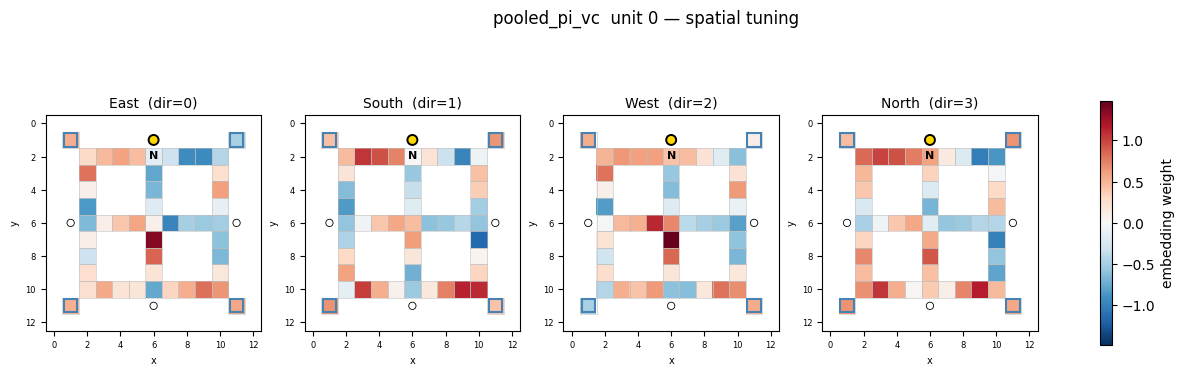

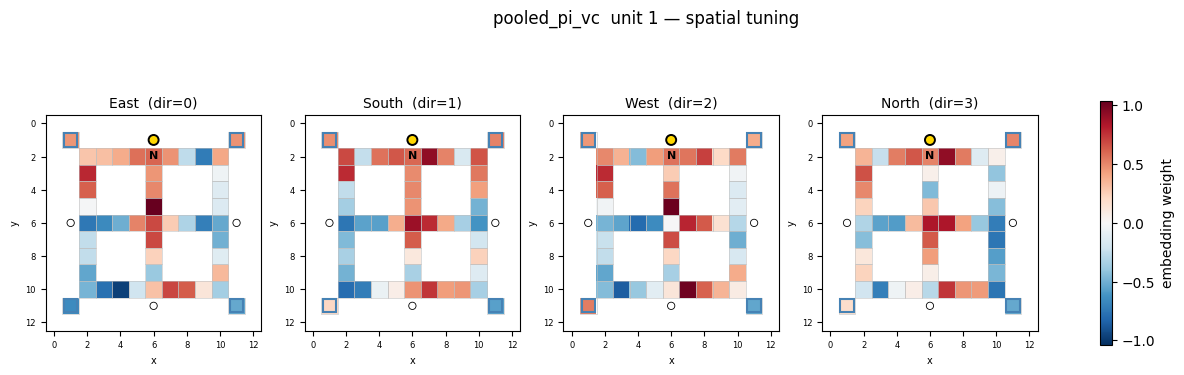

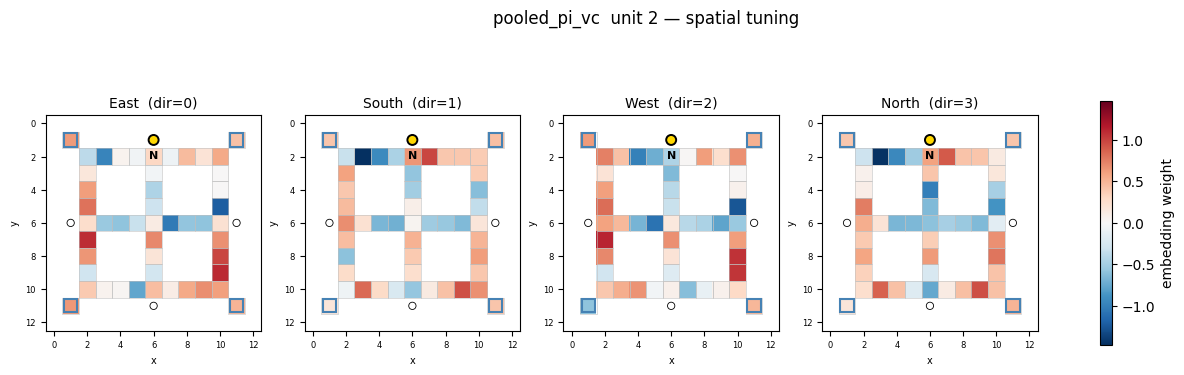

In [9]:
import matplotlib.patches as mpatches
from corner_maze_rl.env.constants import WELL_LOCATIONS, CUE_LOCATIONS

_LABEL0 = next(iter(MODELS))
_MODEL0 = MODELS[_LABEL0]

# ── Which units to render ─────────────────────────────────────────────
# Plot-only knob, so it lives here rather than in the config cell: edit and re-run just this
# cell to browse different units — no retraining needed (training is ~all of the runtime).
_W0     = _MODEL0.pose_representations()   # (196, HIDDEN_UNITS) — the embedding
N_UNITS = _W0.shape[1]

# Units ranked by how strongly they differentiate poses (std of their column).
# A flat unit produces a washed-out map; the top of this list is where the interpretable
# place-field-like structure tends to be.
MOST_TUNED = np.argsort(-_W0.std(axis=0)).tolist()

#   [0, 1, 2]            → the first three
#   MOST_TUNED[:4]       → the four most strongly tuned
#   list(range(N_UNITS)) → all of them
NEURONS_TO_PLOT = [0, 1, 2]


# CUE_LOCATIONS is ordered [East, South, West, North]; after canonicalisation the active
# cue sits at North. Marking it breaks the maze's symmetry — see the note below.
NORTH_CUE = (6, 1)


def _draw_maze_skeleton(ax):
    """Maze floor, wells and cue positions — mirrors notebook 11's helper.

    The 49-cell lattice is symmetric under transpose and 90 degree rotation, so the maze
    outline ALONE cannot reveal a flipped or transposed plot. The filled North cue and the
    x/y tick labels break that symmetry so orientation is checkable by eye.
    """
    for (x, y) in OCCUPIABLE_CELLS:
        ax.add_patch(mpatches.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                        facecolor='none', edgecolor='0.75', lw=0.4))
    for wx, wy in WELL_LOCATIONS:
        ax.add_patch(mpatches.Rectangle((wx - 0.4, wy - 0.4), 0.8, 0.8,
                                        facecolor='none', edgecolor='steelblue', lw=1.5))
    for (cx, cy) in CUE_LOCATIONS:
        is_north = ROTATE_TO_CANONICAL and (cx, cy) == NORTH_CUE
        ax.add_patch(mpatches.Circle((cx, cy), 0.30 if is_north else 0.22,
                                     facecolor='gold' if is_north else 'none',
                                     edgecolor='black', lw=1.4 if is_north else 0.6))
    if ROTATE_TO_CANONICAL:
        ax.annotate('N', xy=NORTH_CUE, xytext=(0, -13), textcoords='offset points',
                    ha='center', fontsize=8, fontweight='bold')

    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(GRID_H - 0.5, -0.5)          # y-down screen coords
    ax.set_aspect('equal')
    ax.set_xticks(range(0, GRID_W, 2))
    ax.set_yticks(range(0, GRID_H, 2))
    ax.tick_params(labelsize=6)
    ax.set_xlabel('x', fontsize=7)
    ax.set_ylabel('y', fontsize=7)


def neuron_maps(W: np.ndarray, unit: int) -> np.ndarray:
    """(N_DIR, GRID_H, GRID_W) of this unit's value per pose; NaN off-maze."""
    w = W[:, unit]
    maps = np.full((N_DIR, GRID_H, GRID_W), np.nan, dtype=np.float32)
    for (x, y, d), i in POSE_TO_IDX.items():
        maps[d, y, x] = w[i]
    return maps


def plot_neuron(W: np.ndarray, unit: int, label: str = ''):
    maps = neuron_maps(W, unit)
    vmax = float(np.nanmax(np.abs(maps)))
    vmax = vmax if vmax > 0 else 1.0

    fig, axes = plt.subplots(1, N_DIR, figsize=(4 * N_DIR, 4.4))
    for d, ax in enumerate(axes):
        im = ax.imshow(maps[d], cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       interpolation='nearest', origin='upper')
        _draw_maze_skeleton(ax)
        ax.set_title(f'{DIR_NAMES[d]}  (dir={d})', fontsize=10)
    fig.suptitle(f'{label}  unit {unit} — spatial tuning'.strip(), fontsize=12)
    fig.colorbar(im, ax=axes, shrink=0.72, label='embedding weight')
    plt.show()


print(f'model={_LABEL0}   units={N_UNITS}')
print(f'most strongly tuned: {MOST_TUNED[:8]}')

# Out-of-range requests are clamped rather than fatal — a narrow layer should not abort the
# whole cell just because the default asked for three units.
_valid   = [n for n in NEURONS_TO_PLOT if 0 <= n < N_UNITS]
_skipped = [n for n in NEURONS_TO_PLOT if n not in _valid]
if _skipped:
    print(f'  [warn] skipping {_skipped}: only {N_UNITS} unit(s), '
          f'so valid indices are 0..{N_UNITS - 1}')
if not _valid:
    _valid = [0]
    print('  nothing valid requested — falling back to unit 0')

print(f'plotting {_valid}')
for _n in _valid:
    plot_neuron(_W0, _n, label=_LABEL0)